# Read in Dataset

In [14]:
import pandas as pd
inspect_df = pd.read_csv(r"C:\Users\jessi\Downloads\DS 340H\Homework4\FoodEstablishmentInspections.csv")
inspect_df.head(20)

C:\Users\jessi\AppData\Local\Temp\ipykernel_40508\658901577.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  inspect_df = pd.read_csv(r"C:\Users\jessi\Downloads\DS 340H\Homework4\FoodEstablishmentInspections.csv")


,businessname,dbaname,legalowner,namelast,namefirst,licenseno,issdttm,expdttm,licstatus,licensecat,...,violdttm,viol_status,status_date,comments,address,city,state,zip,property_id,location
0,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,2018-03-20 14:54:25+00,Fail,NaN,One staff person without hair restraint. Provide,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
1,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,2018-03-20 14:54:25+00,Fail,NaN,Caked on food debris on can opener blade. Clea...,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
2,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,2018-03-20 14:54:25+00,Fail,NaN,Menu was redesigned allergy statement was remo...,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
3,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,2018-08-08 15:54:00+00,Fail,NaN,Several dented cans found on storage shelves. ...,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
4,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,2018-08-08 15:54:00+00,Fail,NaN,Wet wiping cloths found on counter tops . Remo...,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
5,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,2019-02-04 18:06:00+00,Fail,NaN,No labels on bulk containers . Provide,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
6,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,2019-02-04 18:06:00+00,Fail,NaN,Scoops found submerges in flour and other bulk...,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
7,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,NaN,NaN,NaN,NaN,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
8,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,NaN,NaN,NaN,NaN,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"
9,1000 Degrees Pizza,NaN,KHOSLA VIPAN,Pasquriello LLC,Kenneth Pasquariello,313440,2017-08-14 12:49:37+00,2020-01-01 04:59:00+00,Inactive,FS,...,NaN,NaN,NaN,NaN,55 COURT ST,BOSTON,MA,2108.0,156226.0,"(42.35925954972639, -71.05890048027378)"


In [27]:
#clean up city names to get rid of / and //
inpsect_df = inspect_df["city"].str.replace("/", "", regex=False).replace("//","",regex=False)

# Visualization 1: Barplot
Percentage of Violation Statuses (Pass vs Fail) by City in Massachusetts Ordered by Failure Percentage

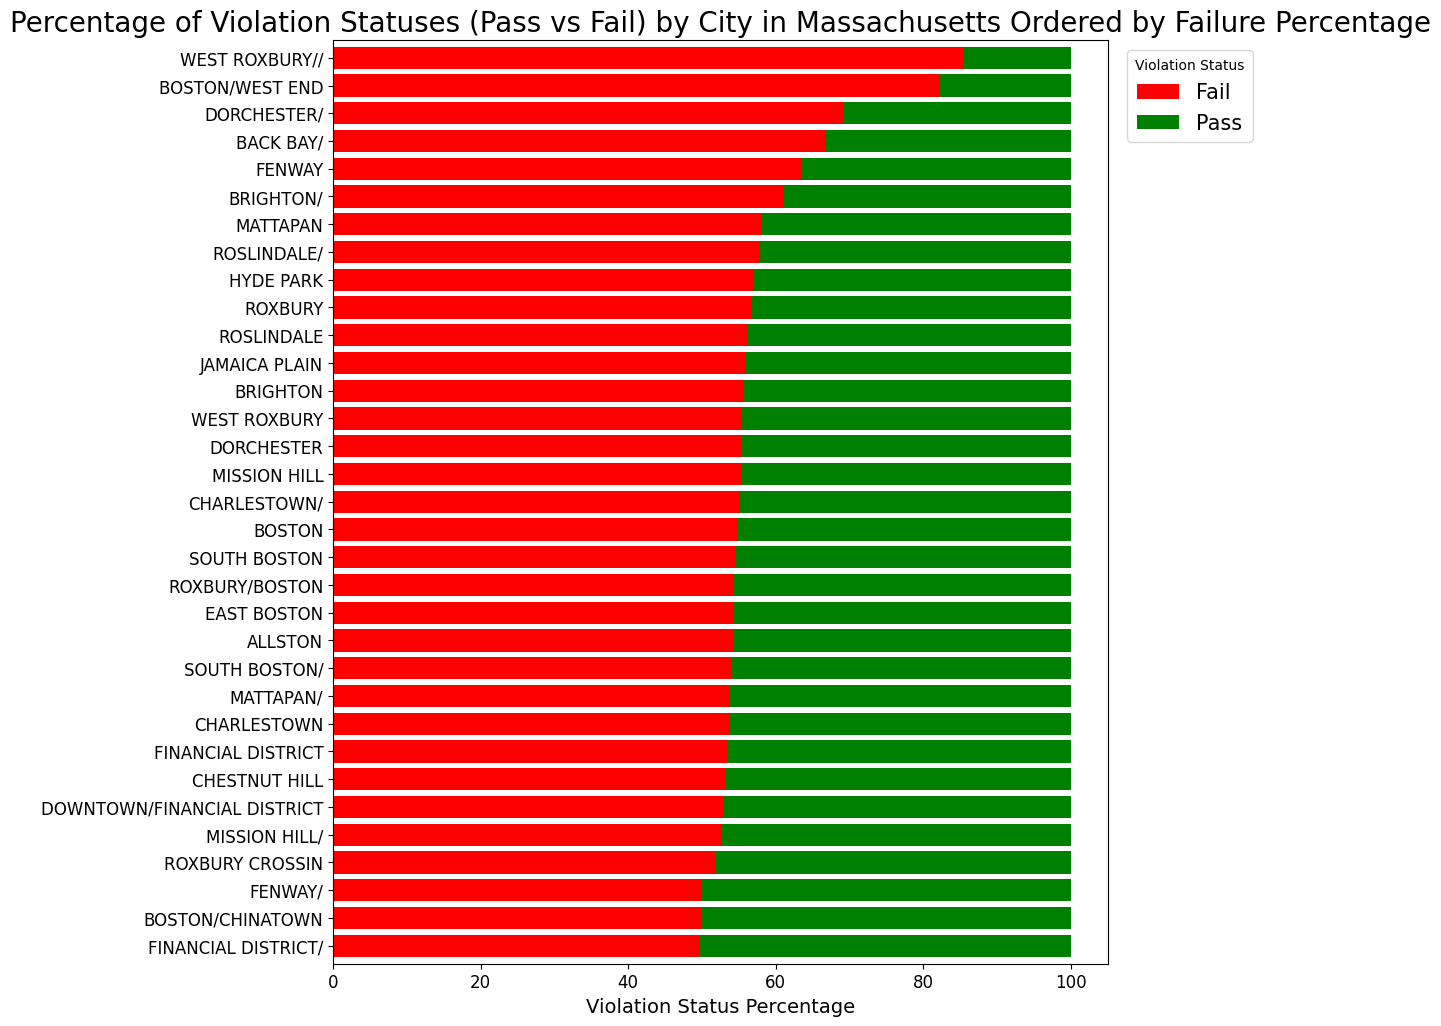

In [53]:
# get columns that we need
total_viol = inspect_df[["businessname", "viol_status","city"]]

# get frequency counts
total_viol_cross = pd.crosstab(
    total_viol["city"],
    total_viol["viol_status"]
)
#convert frequency to percentage
total_viol_percent = total_viol_cross.div(
    total_viol_cross.sum(axis=1),
    axis=0
) * 100

#reordering by fail percentage
total_viol_percent = total_viol_percent.sort_values(
    by="Fail",
    ascending=True
)
# make visual
import matplotlib.pyplot as plt

#make the plot
ax = total_viol_percent.plot(
    kind="barh", #makes the bars horizontal
    stacked=True,
    figsize=(10,12),
    width = 0.8, #bar thickness
    color = ["Red", "Green"] #correspond to order of the columns
)

#axes and titles
ax.set_title("Percentage of Violation Statuses (Pass vs Fail) by City in Massachusetts Ordered by Failure Percentage",
             fontsize=20)
ax.set_ylabel("")
plt.xlabel("Violation Status Percentage",
           fontsize=14)
#make the values on the axis bigger 
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

#legend
plt.legend(title="Violation Status",
           loc="upper right",
           bbox_to_anchor=(1.2, 1), #puts legend outside the graph
           fontsize=15)

#plt.show()

# Visualization 2: Scatterplot
inspection volume by failure rate

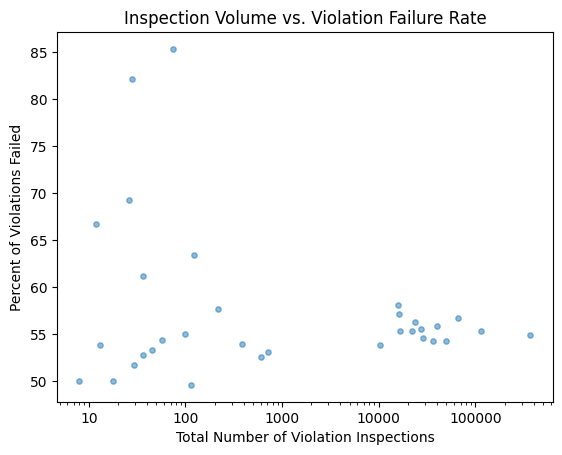

In [102]:

#total number of potential violations inspected
total_viol_cross["Total"] = (
    total_viol_cross["Pass"] +
    total_viol_cross["Fail"]
)

#fail percentage
total_viol_cross["Fail_Percent"] = (
    total_viol_cross["Fail"] /
    total_viol_cross["Total"]
) * 100

#plot visual
ax = total_viol_cross.plot(
    kind="scatter",
    x="Total",
    y="Fail_Percent",
    s=15,
    alpha=0.5
)

#we put them on the log scale so that we can see 
# the lower values and compresses the huge outliers
# (restaurants with many observations)
#but we are keeping the values on the scale as numbers
#to not confuse people with scientfic notation on the log
#scale (ie 10^5)
import matplotlib.ticker as ticker

#x axis
ax.set_xscale("log") #telling matplot lib to scale the axis to be log but observed values themselves are still numeric
ax.xaxis.set_major_formatter(
    ticker.ScalarFormatter()
)
#y axis scale
#ax.set_yscale("log")

#labels and titles
ax.set_xlabel("Total Number of Violation Inspections")
ax.set_ylabel("Percent of Violations Failed")
ax.set_title("Inspection Volume vs. Violation Failure Rate")

plt.show()

# Visualization 3: Lineplot 
how many restaurants for each category are open

In [52]:
inspect_df.columns

Index(['businessname', 'dbaname', 'legalowner', 'namelast', 'namefirst',
       'licenseno', 'issdttm', 'expdttm', 'licstatus', 'licensecat',
       'descript', 'result', 'resultdttm', 'violation', 'viol_level',
       'violdesc', 'violdttm', 'viol_status', 'status_date', 'comments',
       'address', 'city', 'state', 'zip', 'property_id', 'location'],
      dtype='object')

In [57]:
#filter for relevant columns
#business names, license start and expire date, category (dining)
business = inspect_df[['businessname',
                       'issdttm',
                       'expdttm',
                       'descript']]

#on x-axis graph year, number of restaurants for each dining category

In [55]:
business.head()

,businessname,issdttm,expdttm,descript,issue_year,closure_year,year
0,1000 Degrees Pizza,2017-08-14 12:49:37+00:00,2020-01-01 04:59:00+00:00,Eating & Drinking,2017.0,2020.0,"[2017, 2018, 2019, 2020]"
1,1000 Degrees Pizza,2017-08-14 12:49:37+00:00,2020-01-01 04:59:00+00:00,Eating & Drinking,2017.0,2020.0,"[2017, 2018, 2019, 2020]"
2,1000 Degrees Pizza,2017-08-14 12:49:37+00:00,2020-01-01 04:59:00+00:00,Eating & Drinking,2017.0,2020.0,"[2017, 2018, 2019, 2020]"
3,1000 Degrees Pizza,2017-08-14 12:49:37+00:00,2020-01-01 04:59:00+00:00,Eating & Drinking,2017.0,2020.0,"[2017, 2018, 2019, 2020]"
4,1000 Degrees Pizza,2017-08-14 12:49:37+00:00,2020-01-01 04:59:00+00:00,Eating & Drinking,2017.0,2020.0,"[2017, 2018, 2019, 2020]"


In [ ]:
import pandas as pd

# --------------------------------------------------
# STEP 1: Select the columns that we need
# --------------------------------------------------

business = inspect_df[
    ["businessname", "issdttm", "expdttm", "descript"]
].copy()

# keep only unique business/license records
business = business.drop_duplicates(
    subset=[
        "businessname",
        "issdttm",
        "expdttm",
        "descript"
    ]
)

# --------------------------------------------------
# STEP 2: Convert issue and expiration dates
# into datetime format
# --------------------------------------------------

business["issdttm"] = pd.to_datetime(
    business["issdttm"],
    errors="coerce"
)

business["expdttm"] = pd.to_datetime(
    business["expdttm"],
    errors="coerce"
)


# --------------------------------------------------
# STEP 3: Extract the issue year and closure year
# --------------------------------------------------

business["issue_year"] = business["issdttm"].dt.year
business["closure_year"] = business["expdttm"].dt.year


# --------------------------------------------------
# STEP 4: Remove rows where we don't have the
# necessary year information
# --------------------------------------------------

business = business.dropna(
    subset=["issue_year", "closure_year"]
)


# --------------------------------------------------
# STEP 5: Create a list of every year that each
# business was considered open
#
# Example:
# issue_year = 2018
# closure_year = 2021
#
# year = [2018, 2019, 2020, 2021]
# --------------------------------------------------

business["year"] = business.apply(
    lambda row: list(
        range(
            int(row["issue_year"]),
            int(row["closure_year"]) + 1
        )
    ),
    axis=1
)


# --------------------------------------------------
# STEP 6: Turn each year into its own row
# --------------------------------------------------

business_year = business.explode("year")


# --------------------------------------------------
# STEP 7: Create a crosstab
#
# Rows = year
# Columns = business/dining type
# Values = frequency
# --------------------------------------------------

business_crosstab = pd.crosstab(
    business_year["year"],
    business_year["descript"]
)

#set year to be int not float
business_crosstab.index=business_crosstab.index.astype(int)

In [67]:
business_crosstab.head()


descript,Eating & Drinking,Eating & Drinking w/ Take Out,Mobile Food Walk On,Retail Food
year,,,,
2007,88,92,0,126
2008,149,169,0,248
2009,147,179,0,203
2010,126,162,0,165
2011,575,336,25,494


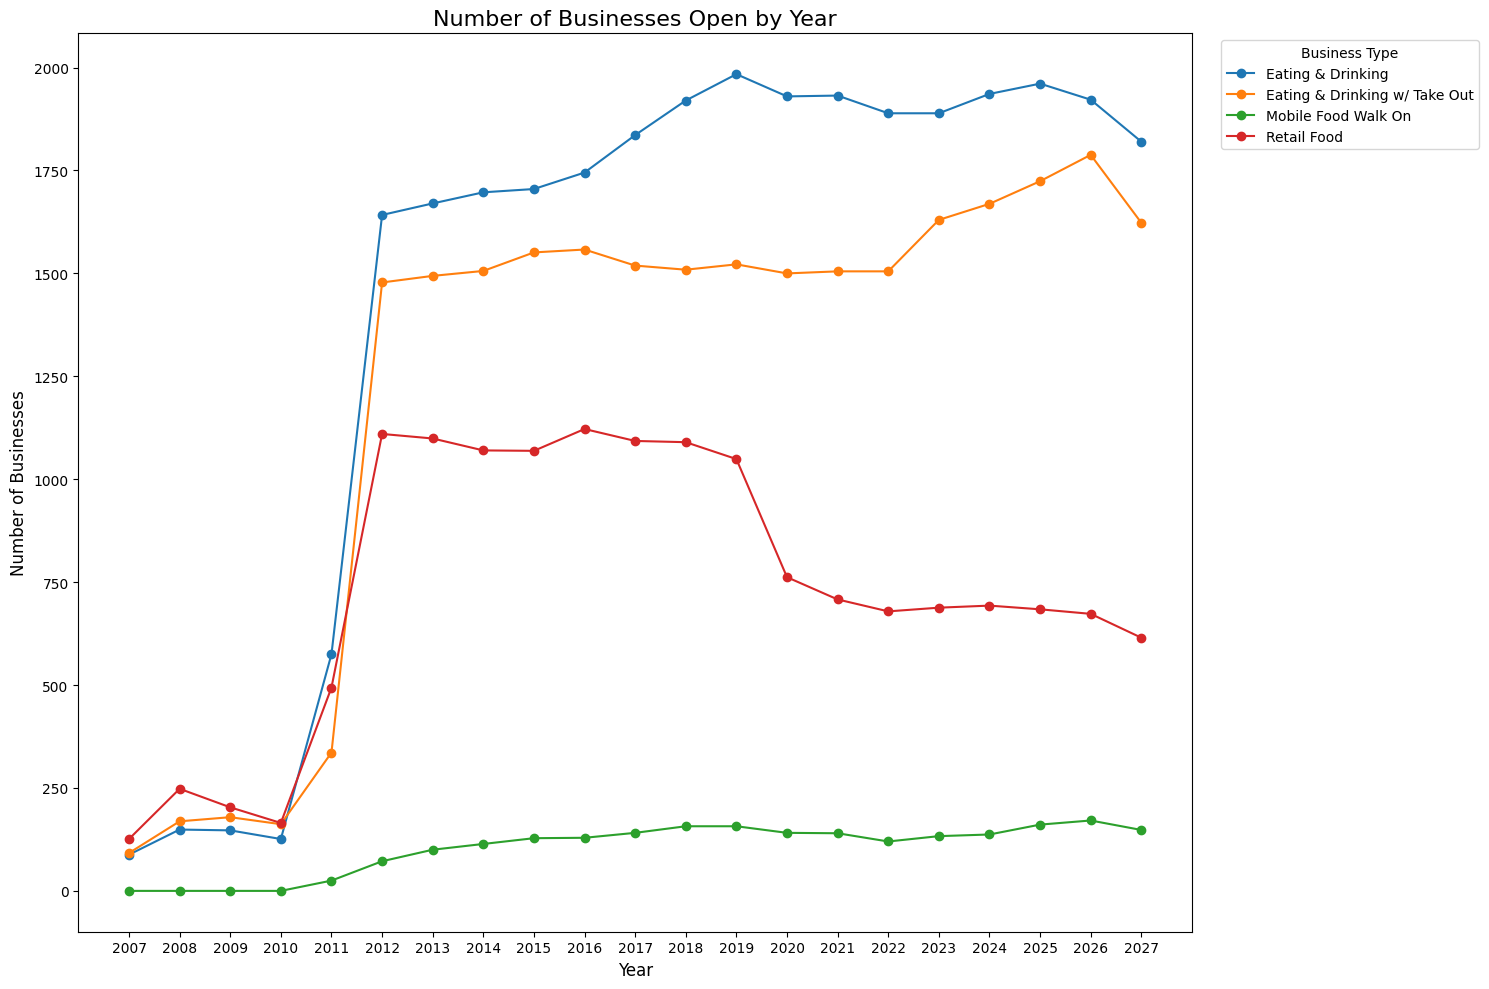

In [66]:
#make the line plot
import matplotlib.pyplot as plt

ax = business_crosstab.plot(
    kind="line",
    marker="o",
    figsize=(15, 10)
)

# Labels
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Businesses", fontsize=12)

# Title
ax.set_title(
    "Number of Businesses Open by Year",
    fontsize=16
)

#every year
ax.set_xticks(business_crosstab.index)
# Tick label sizes
ax.tick_params(
    axis="both",
    labelsize=10
)

# Legend
ax.legend(
    title="Business Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Visualization 4: Boxplot 
violation failure rate for businesses by year 

In [ ]:
#filter for relevant columns
total_inspect = inspect_df[[
    "businessname"
]]
#year and health inspections
#make sinaplots for year on x-axis and number of violations on y axis

In [95]:
# 1. Convert violation date to datetime
inspect_df["violdttm"] = pd.to_datetime(
    inspect_df["violdttm"],
    errors="coerce"
)

# 2. Extract violation year
inspect_df["viol_year"] = (
    inspect_df["violdttm"]
    .dt.year
    .astype("Int64")
)

# 3. Count how many unique locations each business name
#    has within each year
location_counts = (
    inspect_df
    .groupby(["viol_year", "businessname"])["address"]
    .nunique()
    .reset_index(name="num_locations")
)

# 4. Keep business-year combinations with only one location
single_location = location_counts[
    location_counts["num_locations"] == 1
]

# 5. Filter the original data to ONLY those businesses/years
single_location_df = inspect_df.merge(
    single_location[["viol_year", "businessname"]],
    on=["viol_year", "businessname"],
    how="inner"
)

#6. failure rate
# Count Pass and Fail records for each business within each year
failure_rate = pd.crosstab(
    index=[
        single_location_df["viol_year"],
        single_location_df["businessname"]
    ],
    columns=single_location_df["viol_status"]
).reset_index()

failure_rate["fail_percent"] = (
    failure_rate["Fail"] /
    (failure_rate["Fail"] + failure_rate["Pass"])
) * 100

failure_rate.head()

viol_status,viol_year,businessname,Fail,Pass,fail_percent
0,2006,RIDDICK'S HOUSE OF PIZZA,0,2,0.000000
1,2007,RIDDICK'S HOUSE OF PIZZA,1,4,20.000000
2,2007,149 Eat Street,10,10,50.000000
3,2007,163 Vietnamese Sandwich,1,0,100.000000
4,2007,21 ST. AMENDMENT,31,21,59.615385


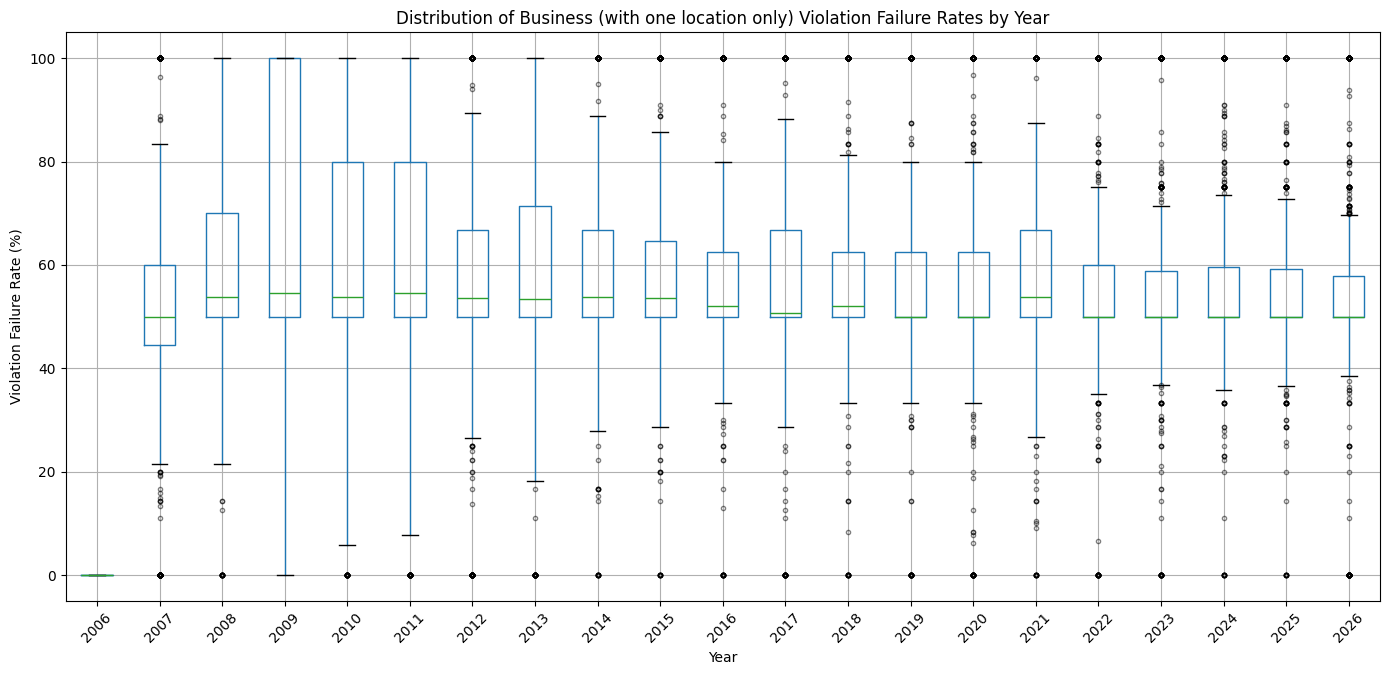

In [103]:
flierprops = {
    "marker": "o",
    "markersize": 3,
    "alpha": 0.5
}

failure_rate.boxplot(
    column="fail_percent",
    by="viol_year",
    figsize=(14, 7),
    flierprops=flierprops
)

plt.xlabel("Year")
plt.ylabel("Violation Failure Rate (%)")
plt.title("Distribution of Business (with one location only) Violation Failure Rates by Year")
plt.suptitle("")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()